# What the model actually sees

This notebook walks through the exact preprocessing pipeline the trained tyre-pose model applies, step by step, on frames pulled from the **synthetic simulator clips** used for training and blind evaluation.

For each sample frame, we show:
- The original rendered frame as decoded from the clip
- The letterboxed 960x960 image (resize + pad) that is fed to the network
- The normalized tensor the network mathematically sees (values in [0,1], as a sanity-check visualization — visually identical to the letterboxed image, but this is the literal array shape/dtype/range going into the model)
- The model's raw output overlaid on the full frame (box + 4 tyre keypoints + confidence)
- **A zoomed-in crop with the 4 tyre keypoints plotted large and labeled by name** (front_left/front_right/rear_left/rear_right) with each keypoint's own confidence — this is the actual tyre-based detection the model produces; it's easy to miss in the full-frame panel because the car (and therefore each tyre dot) is small relative to the whole image.

Run cells top to bottom.

In [1]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from ultralytics.data.augment import LetterBox

WEIGHTS = r"C:/Users/arnav/trackshift_runs/kerb960/experiment/selected.pt"
IMGSZ = 960
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = YOLO(WEIGHTS)
print('Loaded weights:', WEIGHTS)
print('Device:', DEVICE)
print('imgsz:', IMGSZ)

Loaded weights: C:/Users/arnav/trackshift_runs/kerb960/experiment/selected.pt
Device: cuda
imgsz: 960


## Helper functions

`letterbox()` replicates exactly what Ultralytics does internally before inference: resize the longest side to `imgsz`, keep aspect ratio, pad the rest with grey (114,114,114).

`to_model_tensor()` shows the literal array the network's forward pass receives: BGR->RGB, HWC->CHW, uint8[0,255] -> float32[0,1].

In [2]:
def letterbox(img_bgr, size=IMGSZ):
    lb = LetterBox(new_shape=(size, size), auto=False, stride=32)
    return lb(image=img_bgr)

def to_model_tensor(letterboxed_bgr):
    rgb = cv2.cvtColor(letterboxed_bgr, cv2.COLOR_BGR2RGB)
    chw = rgb.transpose(2, 0, 1)
    tensor = chw.astype(np.float32) / 255.0
    return tensor

KEYPOINT_NAMES = ['front_left', 'front_right', 'rear_left', 'rear_right']
KEYPOINT_COLORS = ['#39FF14', '#FFFFFF', '#FFD700', '#FF3B30']  # green, white, gold, red

FIGSIZE = (12, 9)  # each stage gets its own large figure

def show_one(img_rgb, title, extent=None, xlim=None, ylim=None):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.imshow(img_rgb, extent=extent)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_title(title, fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

def run_and_show(img_path, title):
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        raise FileNotFoundError(img_path)
    lb_bgr = letterbox(img_bgr)
    tensor = to_model_tensor(lb_bgr)

    results = model.predict(source=str(img_path), imgsz=IMGSZ, conf=.1, max_det=8, device=DEVICE, verbose=False)
    r = results[0]
    # kpt_radius bumped up (default 5) so tyre points are actually visible at figure scale.
    annotated_bgr = r.plot(kpt_radius=10, line_width=3)
    n_det = len(r.boxes)

    print(f'\n{"="*90}\n{title}\n{"="*90}')

    show_one(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),
              f'1. Original ({img_bgr.shape[1]}x{img_bgr.shape[0]})')

    show_one(cv2.cvtColor(lb_bgr, cv2.COLOR_BGR2RGB),
              f'2. Letterboxed model input ({IMGSZ}x{IMGSZ}, grey pad)')

    show_one(tensor.transpose(1, 2, 0),
              f'3. Normalized tensor  shape={tensor.shape}, dtype={tensor.dtype}, range=[{tensor.min():.2f},{tensor.max():.2f}]')

    conf_str = ', '.join(f'{c:.2f}' for c in r.boxes.conf.cpu().numpy()) if n_det else 'none'
    show_one(cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB),
              f'4. Model output (full frame)  {n_det} detection(s), conf=[{conf_str}]')

    # Zoomed-in crop around the top detection's box, with the 4 tyre keypoints
    # plotted large and labeled by name -- this is the actual tyre-based detection.
    fig, ax = plt.subplots(figsize=FIGSIZE)
    if n_det:
        top = int(np.argmax(r.boxes.conf.cpu().numpy()))
        x1, y1, x2, y2 = r.boxes.xyxy.cpu().numpy()[top]
        pad = 0.25 * max(x2 - x1, y2 - y1)
        cx1, cy1 = max(0, int(x1 - pad)), max(0, int(y1 - pad))
        cx2, cy2 = min(lb_bgr.shape[1], int(x2 + pad)), min(lb_bgr.shape[0], int(y2 + pad))
        crop = cv2.cvtColor(lb_bgr[cy1:cy2, cx1:cx2], cv2.COLOR_BGR2RGB)
        ax.imshow(crop, extent=[cx1, cx2, cy2, cy1])
        ax.set_xlim(cx1, cx2)
        ax.set_ylim(cy2, cy1)

        kpts = r.keypoints.data.cpu().numpy()[top]  # (4, 3): x, y, conf
        for (kx, ky, kconf), name, color in zip(kpts, KEYPOINT_NAMES, KEYPOINT_COLORS):
            ax.scatter([kx], [ky], s=320, c=color, edgecolors='black', linewidths=1.5, zorder=5)
            ax.annotate(f'{name}\n{kconf:.2f}', (kx, ky), textcoords='offset points', xytext=(10, 10),
                        color='white', fontsize=11, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.65))
        ax.set_title('5. Tyre keypoints, zoomed  (dot = position, number = per-keypoint confidence)', fontsize=14)
    else:
        ax.text(0.5, 0.5, 'No detection above conf=0.1', ha='center', va='center')
        ax.set_title('5. Tyre keypoints, zoomed', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    return r

## Synthetic clip demo

Pulled from the actual blind evaluation set the model was scored on (`experiment/fresh_blind/`). We sample a handful of different incidents/angles and grab a representative frame from each, to show the model running across varied clips rather than just one.

In [3]:
BLIND_ROOT = Path(r"C:/Users/arnav/trackshift_runs/kerb960/experiment/fresh_blind")
FRAME_DUMP_DIR = Path(r"C:/Users/arnav/trackshift_runs/kerb960/notebook_sample_frames")
FRAME_DUMP_DIR.mkdir(parents=True, exist_ok=True)

# A handful of different incidents/camera angles from the blind set, for variety.
SAMPLE_CLIPS = [
    ("034764aba12aec43_a00", "Incident 034764a..., angle 0"),
    ("2d3afa02e0fb2691_a01", "Incident 2d3afa0..., angle 1"),
    ("570c454ec8bf5599_a02", "Incident 570c454..., angle 2"),
    ("cf6e05bf7aef8126_a02", "Incident cf6e05b..., angle 2"),
]

def extract_middle_frame(clip_id):
    video_path = BLIND_ROOT / clip_id / "original.mp4"
    cap = cv2.VideoCapture(str(video_path))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, n_frames // 2)
    ok, frame = cap.read()
    cap.release()
    assert ok, f'failed to read frame from {video_path}'
    out_path = FRAME_DUMP_DIR / f"{clip_id}.png"
    cv2.imwrite(str(out_path), frame)
    return out_path, n_frames // 2, n_frames

for clip_id, _ in SAMPLE_CLIPS:
    out_path, idx, total = extract_middle_frame(clip_id)
    print(f'{clip_id}: extracted frame {idx}/{total} -> {out_path}')

034764aba12aec43_a00: extracted frame 12/24 -> C:\Users\arnav\trackshift_runs\kerb960\notebook_sample_frames\034764aba12aec43_a00.png
2d3afa02e0fb2691_a01: extracted frame 12/24 -> C:\Users\arnav\trackshift_runs\kerb960\notebook_sample_frames\2d3afa02e0fb2691_a01.png
570c454ec8bf5599_a02: extracted frame 12/24 -> C:\Users\arnav\trackshift_runs\kerb960\notebook_sample_frames\570c454ec8bf5599_a02.png


cf6e05bf7aef8126_a02: extracted frame 12/24 -> C:\Users\arnav\trackshift_runs\kerb960\notebook_sample_frames\cf6e05bf7aef8126_a02.png



Incident 034764a..., angle 0


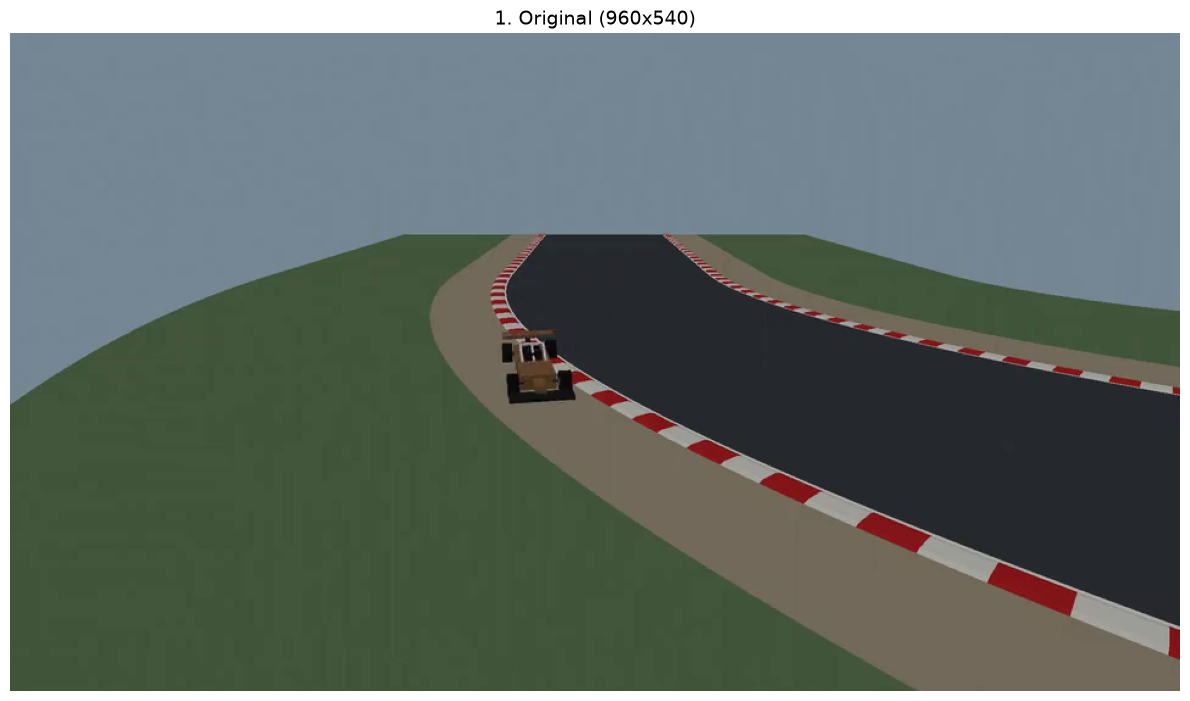

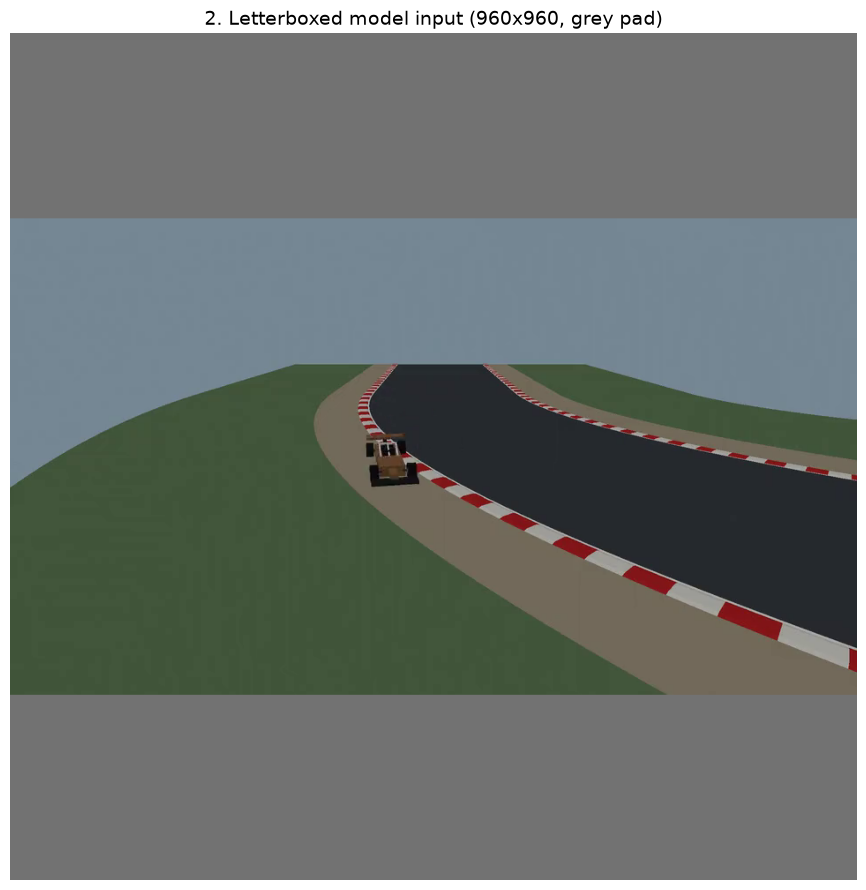

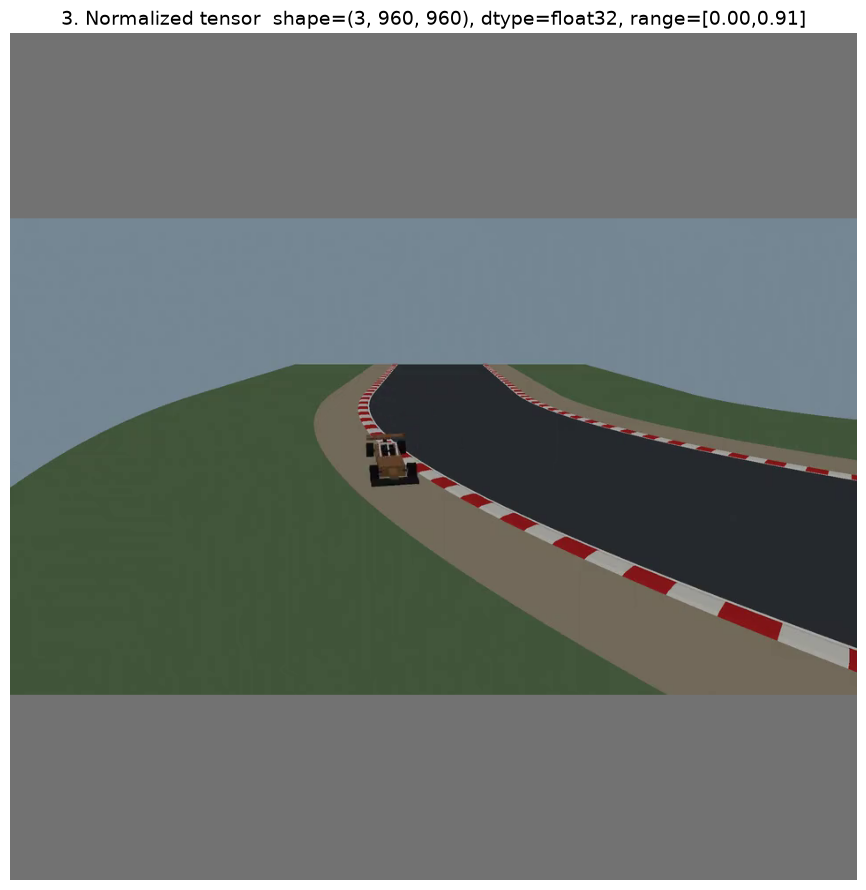

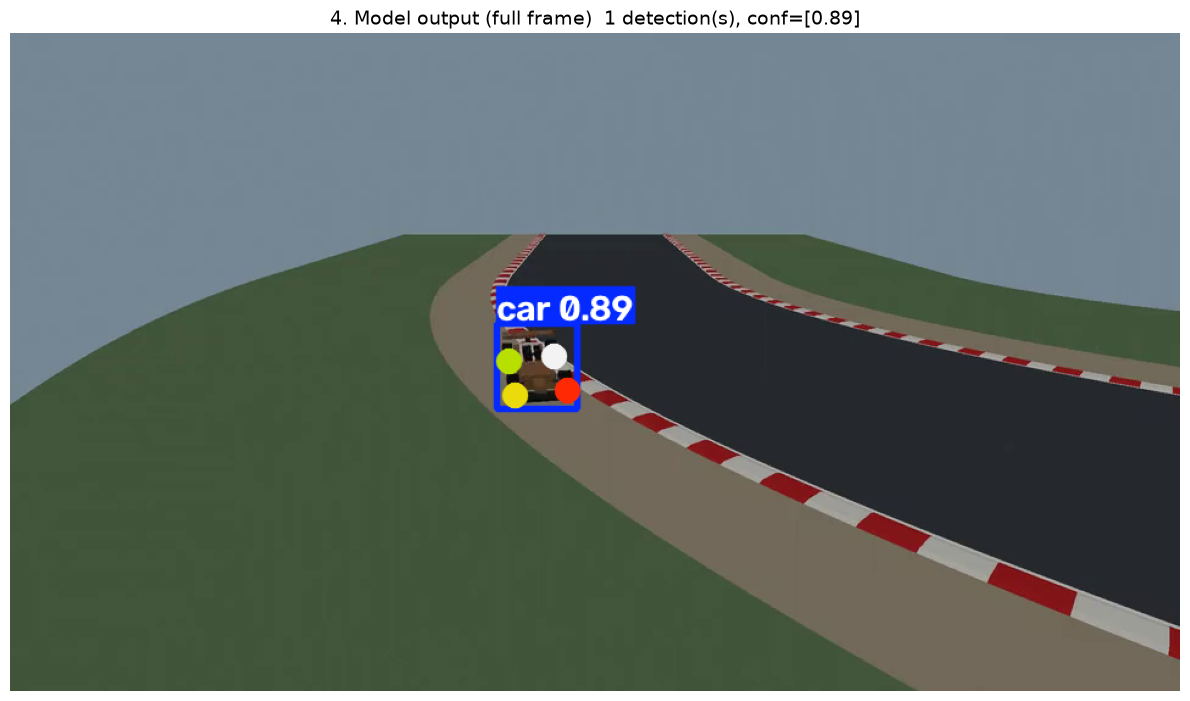

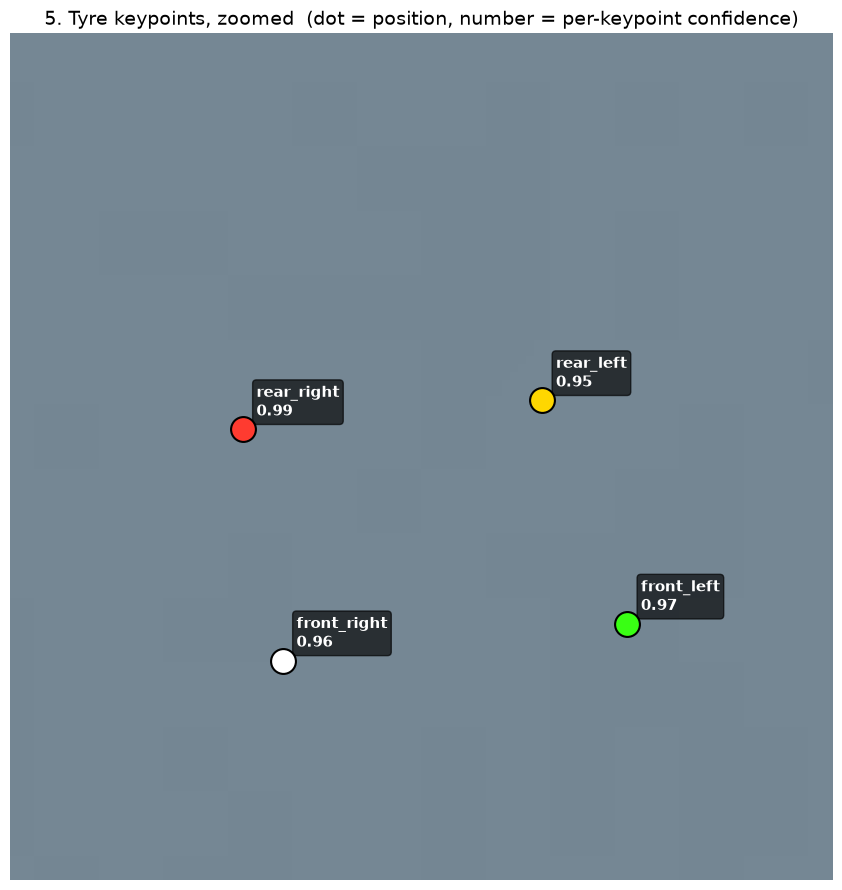


Incident 2d3afa0..., angle 1


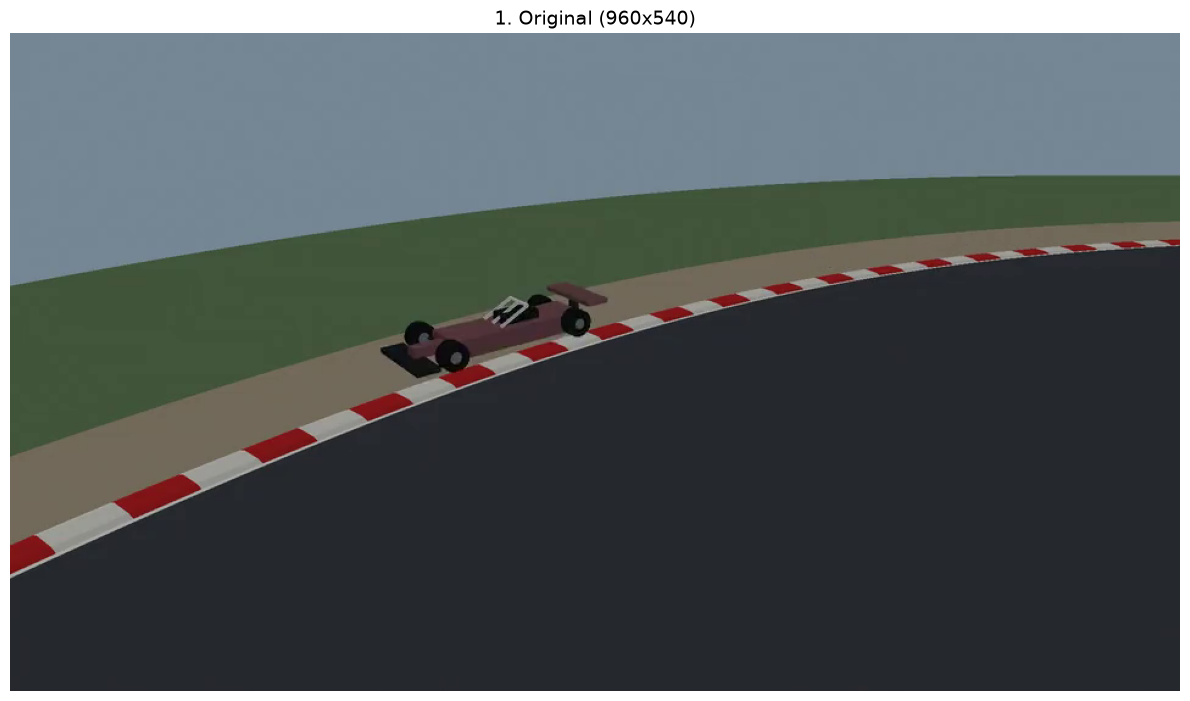

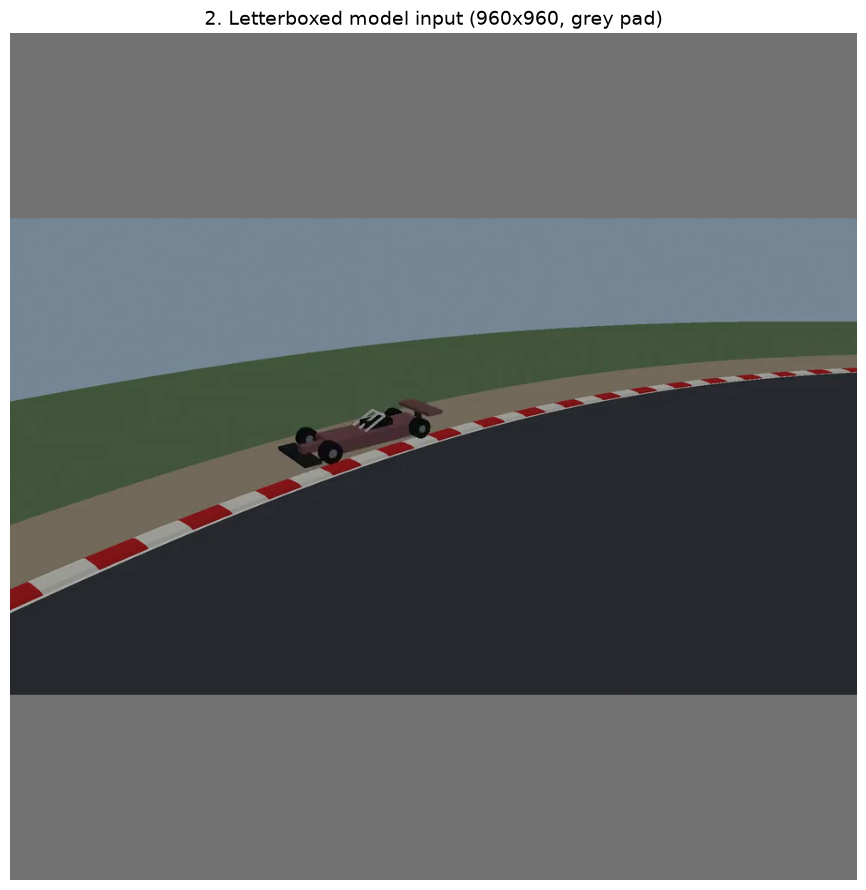

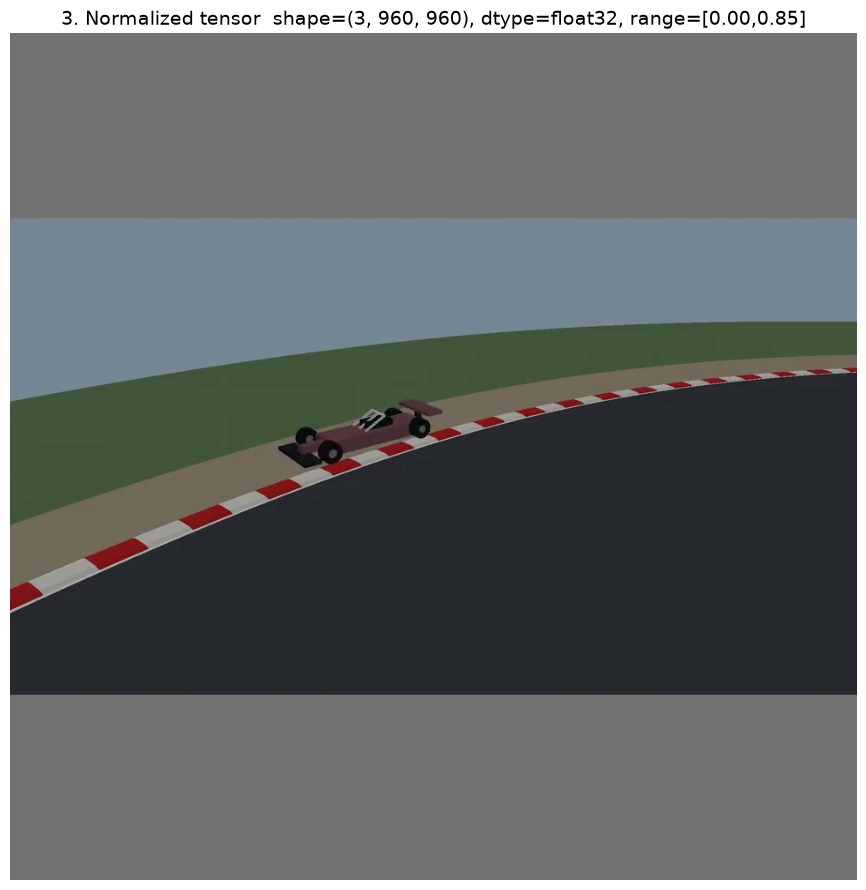

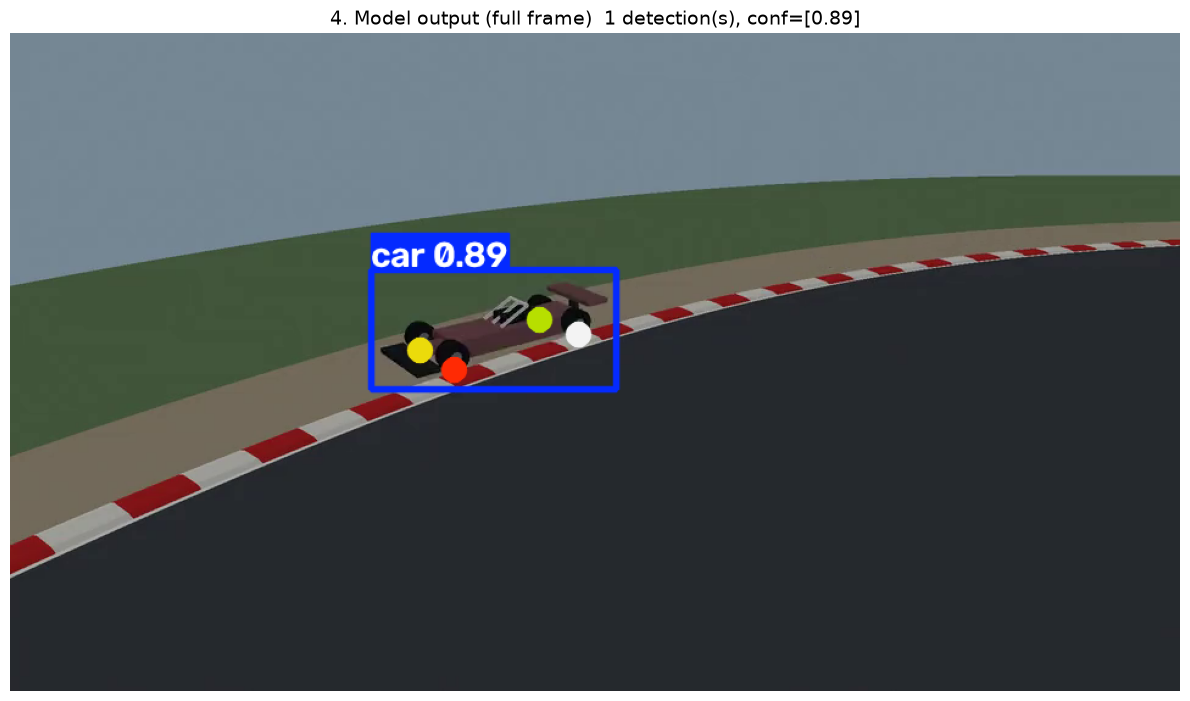

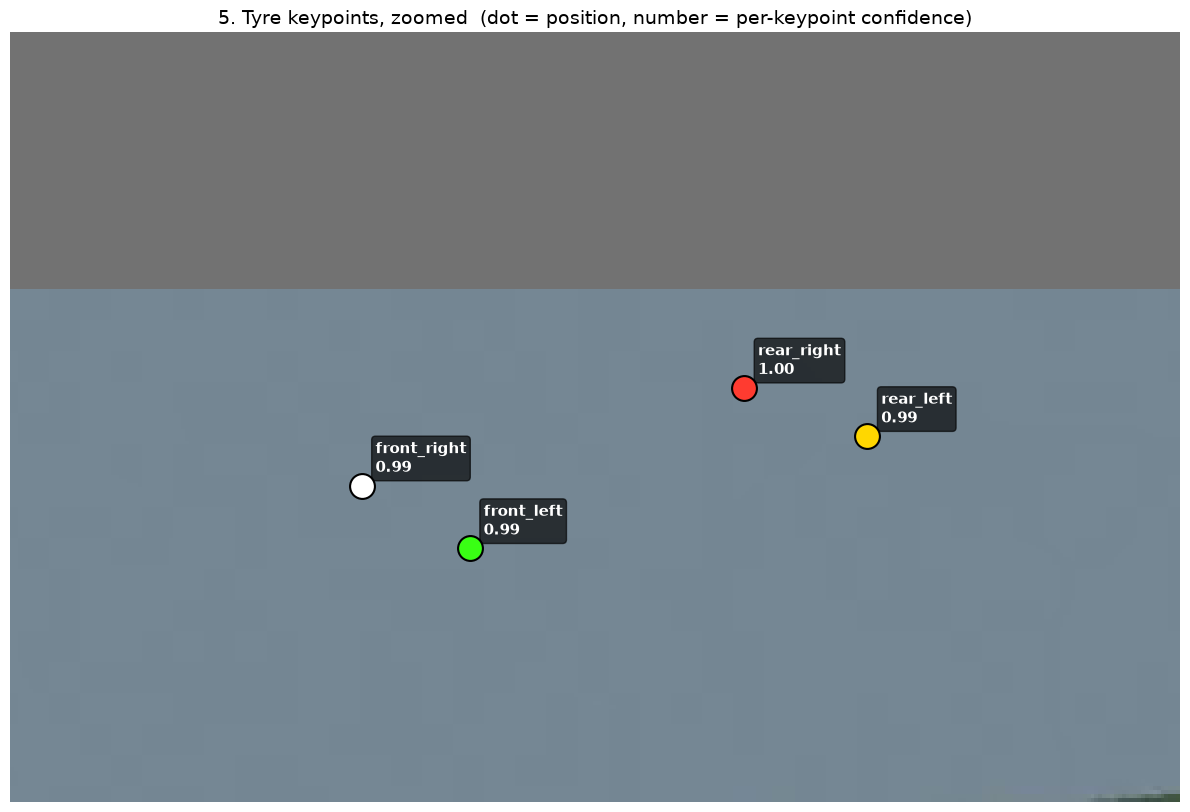


Incident 570c454..., angle 2


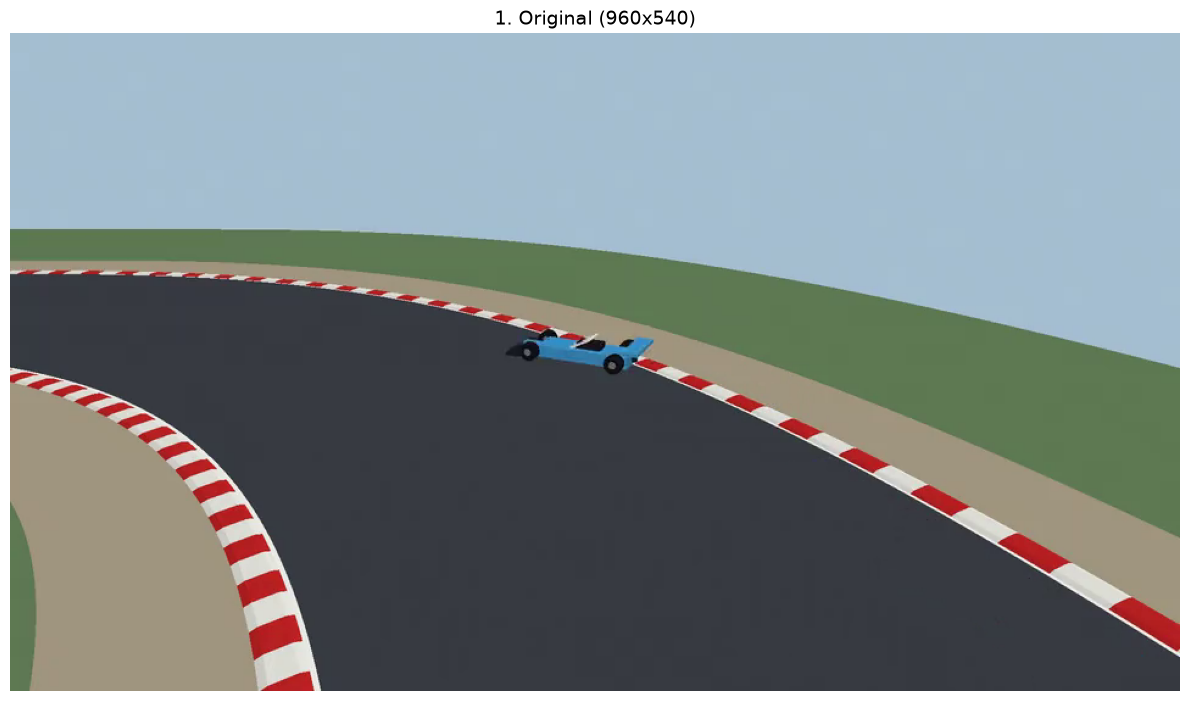

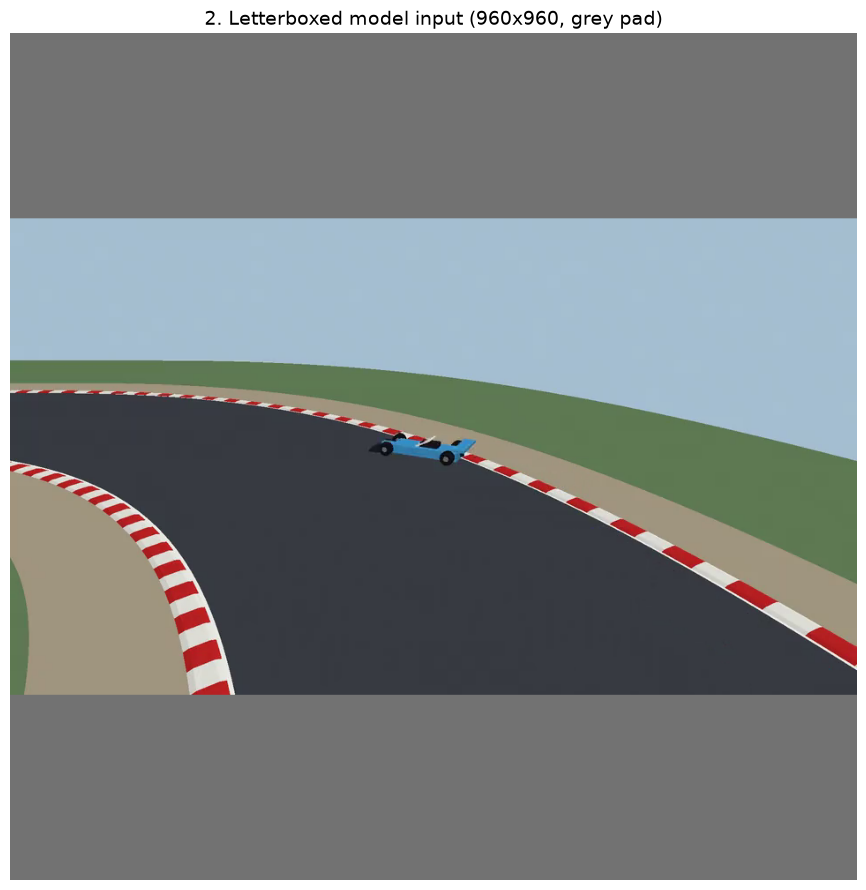

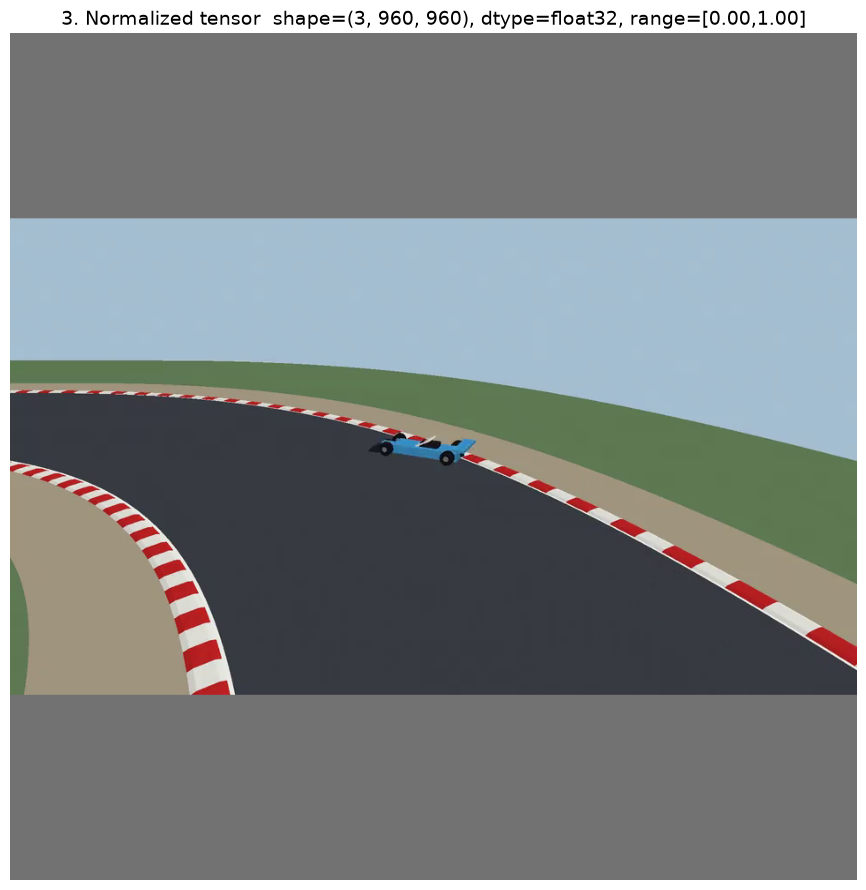

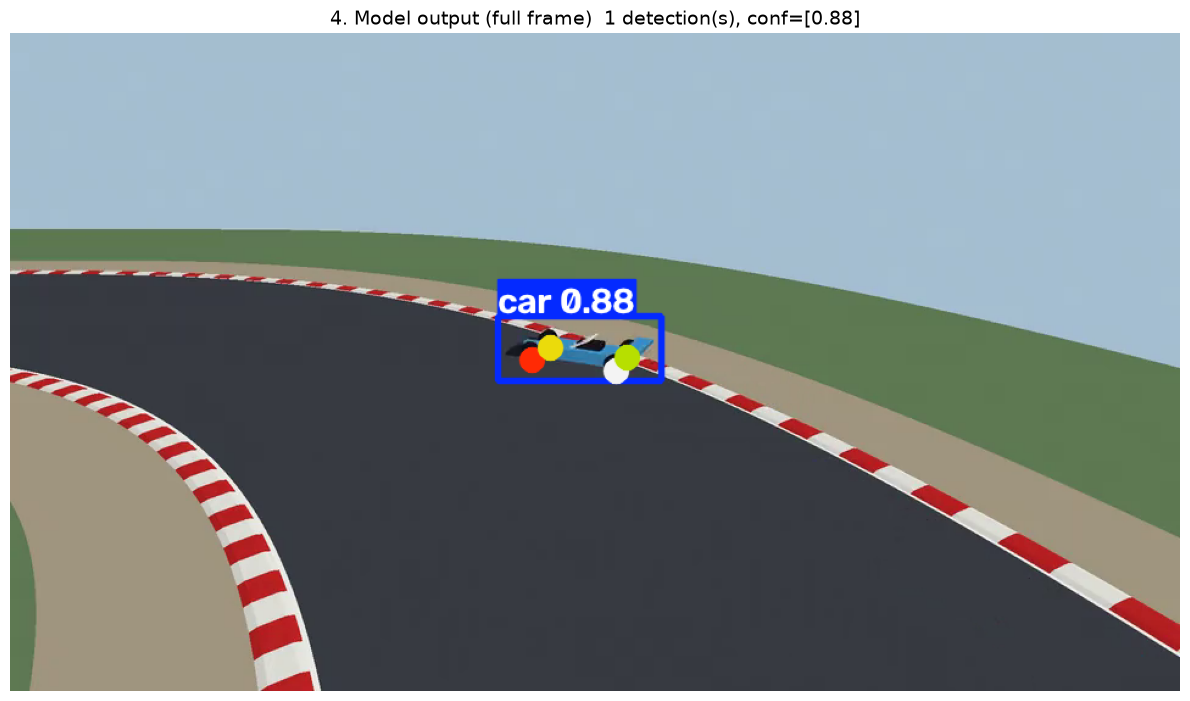

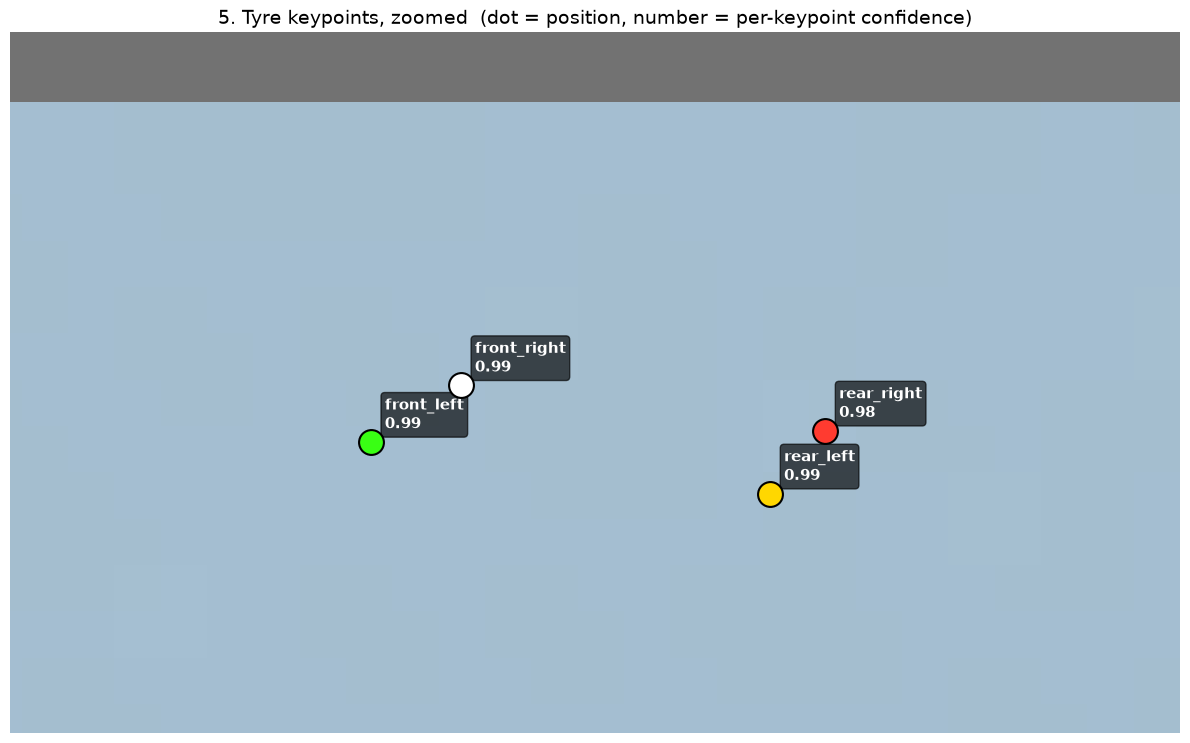


Incident cf6e05b..., angle 2


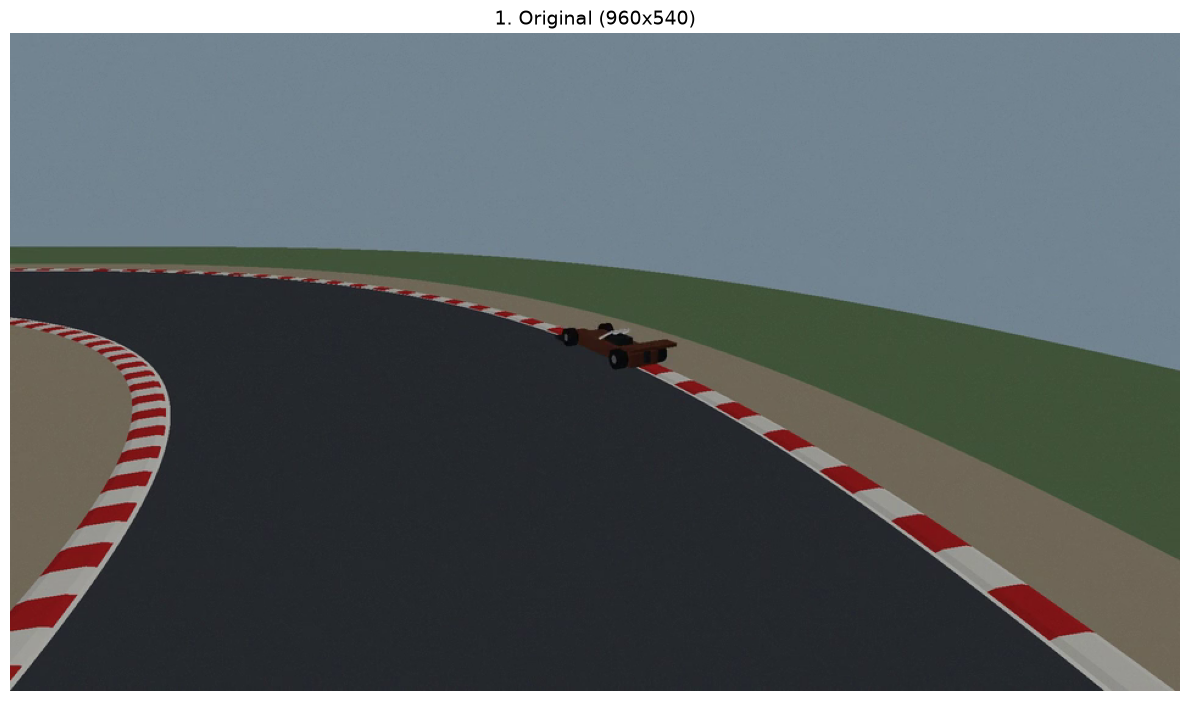

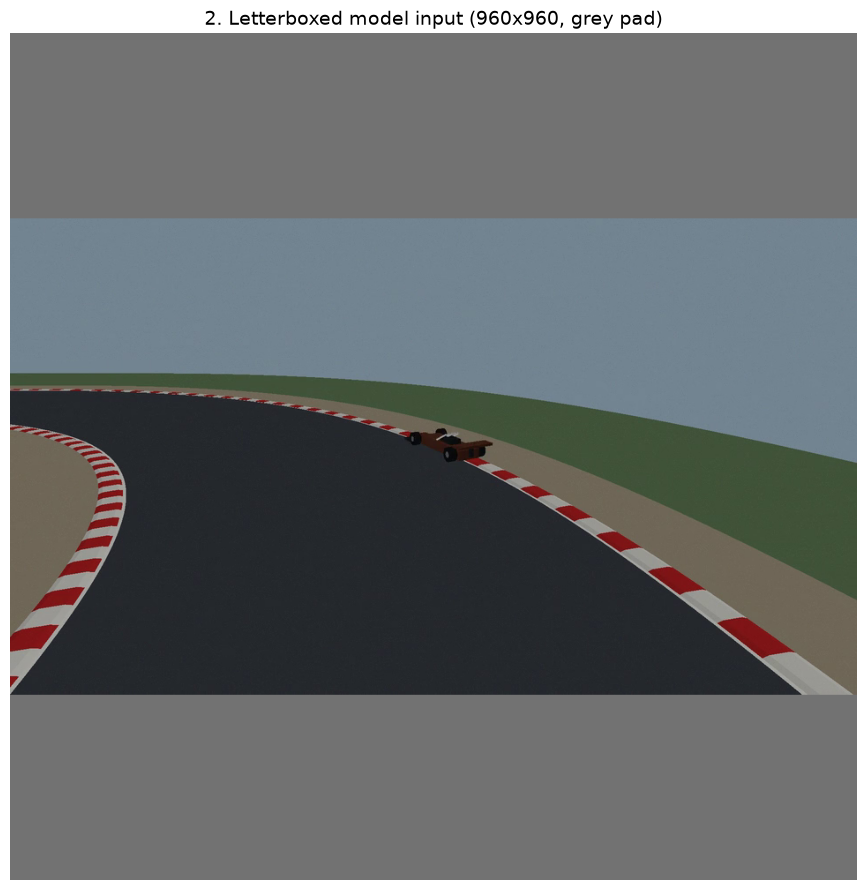

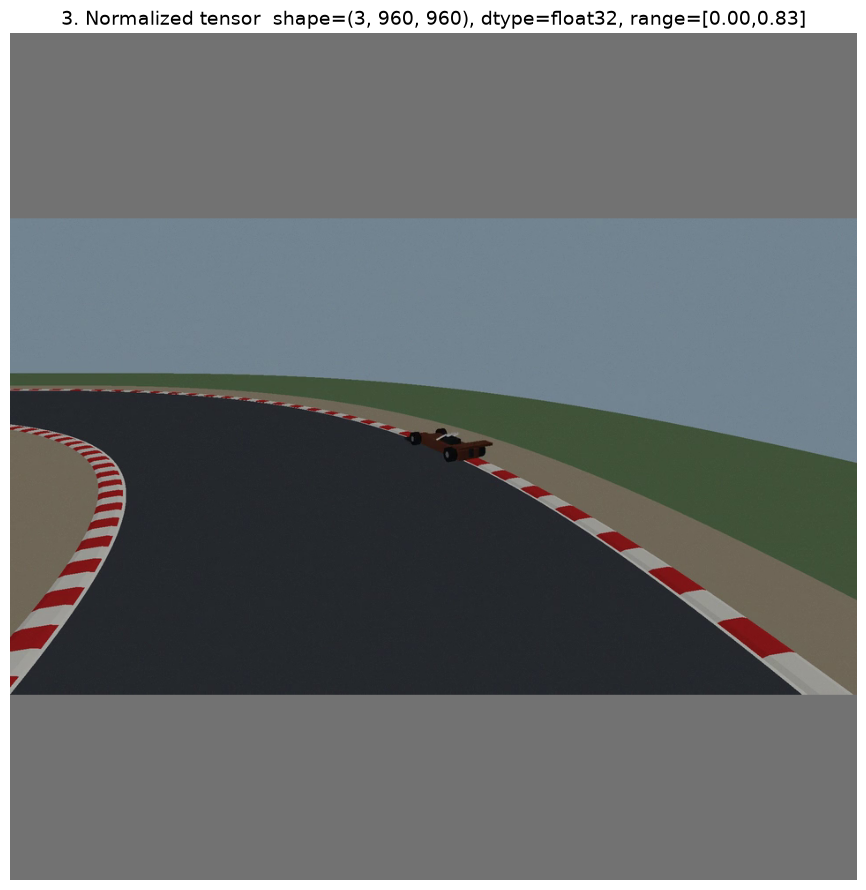

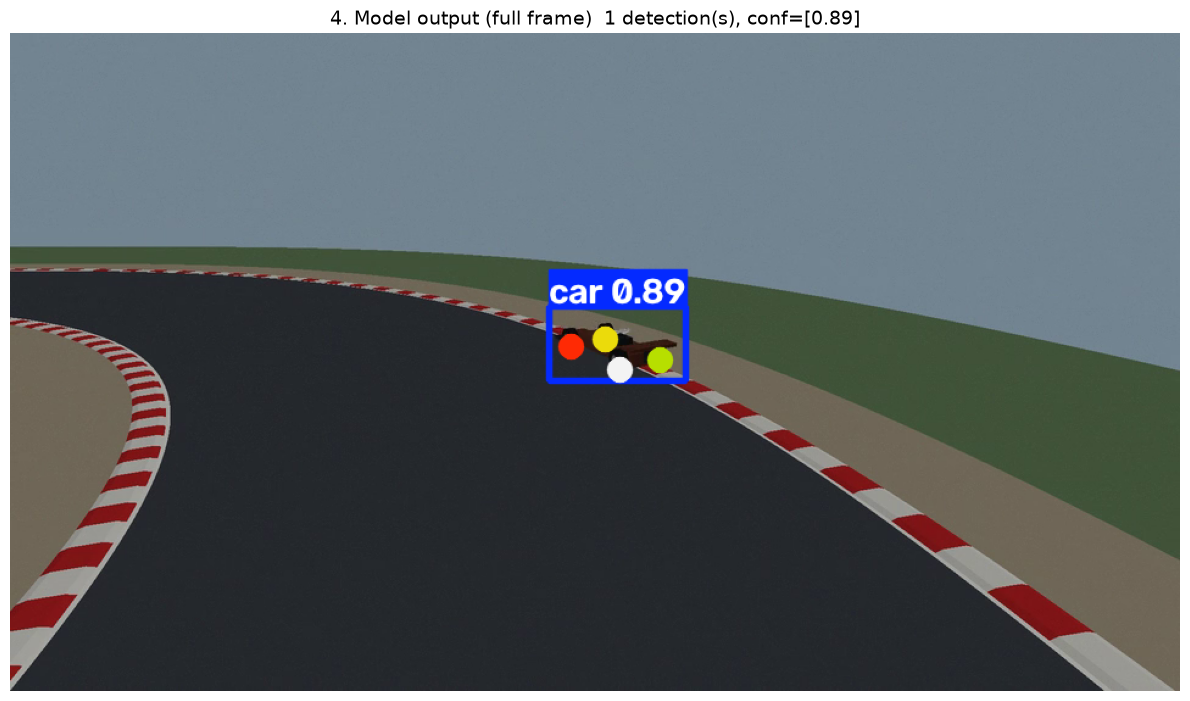

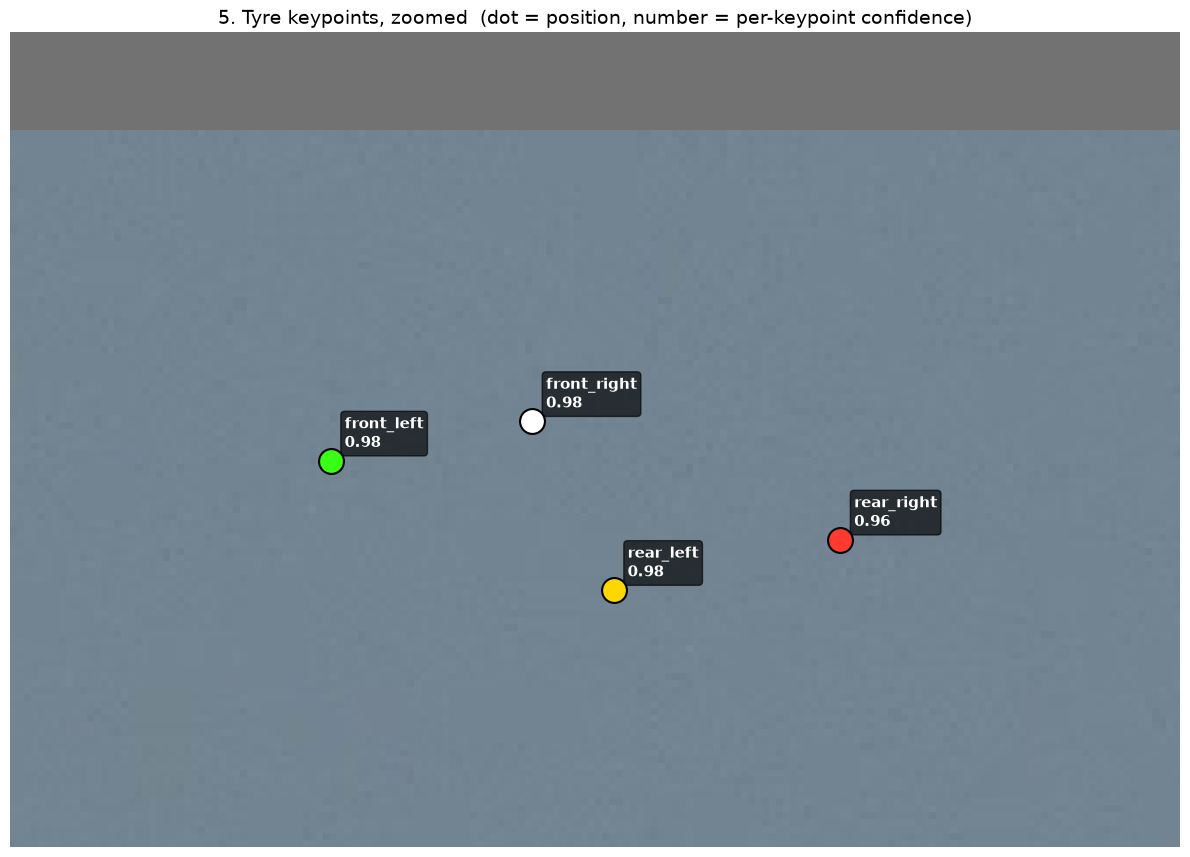

In [4]:
for clip_id, title in SAMPLE_CLIPS:
    frame_path = FRAME_DUMP_DIR / f"{clip_id}.png"
    run_and_show(frame_path, title)